# P0 · Functions with clear contracts

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.6 · Functions with clear contracts

A function contract states valid inputs, returned values, and side effects. Type hints describe intent; checks enforce it.

**Prerequisites:** Follow iteration and unpacking

**Predict:** Can three source positions supply three next-character targets?

**Mental model:** A reusable function needs a clear agreement with its caller. State what values it accepts, what it returns, and whether it changes any inputs.

<a data-compat-cell="p0-functions-and-f-strings"></a>

### P0.6.1 · Understand the need

A reusable function needs a clear agreement with its caller. State what values it accepts, what it returns, and whether it changes any inputs.

A training window requires one more source position than its context length. Otherwise the final input has no next-character target.

Defaults make a common choice convenient, while keyword arguments make a call easier to read. Neither replaces checking the actual input.

Returning two values packages them into a tuple. The caller can unpack that tuple into two descriptive names.

A type hint documents an expected kind of value. Python does not automatically enforce ordinary type hints during a function call.

### P0.6.2 · Follow the values

The source IDs are zero through five. The default context size is three, and the experiment chooses a starting position.

With start zero, the input contains zero, one and two. The function constructs this slice without mutating the source list.

The targets contain one, two and three. Each target names the position immediately after its corresponding input.

Inspect the original list after the call. It still contains all six IDs because slicing created new outer lists.

The two returned windows have equal length and the expected overlap. Move the start once and check that both windows move together.

In [3]:
FRAMES.clear()
change = 0
def window(ids: list[int], start: int, size: int = 3):
    if start < 0 or size < 1 or start + size >= len(ids):
        raise ValueError("Need a complete window plus its next target")
    return ids[start:start+size], ids[start+1:start+size+1]
ids = [0, 1, 2, 3, 4, 5]
show("Arguments", {"ids": ids, "start": change, "size": 3})
x, y = window(ids, start=change)
show("Returned inputs", x)
show("Returned targets", y)
show("Input list is unchanged", ids)
show("Contract", {"equal lengths": len(x) == len(y), "next-token shift": x[1:] == y[:-1]})

Arguments: {"ids": [0, 1, 2, 3, 4, 5], "start": 0, "size": 3}
Returned inputs: [0, 1, 2]
Returned targets: [1, 2, 3]
Input list is unchanged: [0, 1, 2, 3, 4, 5]
Contract: {"equal lengths": true, "next-token shift": true}


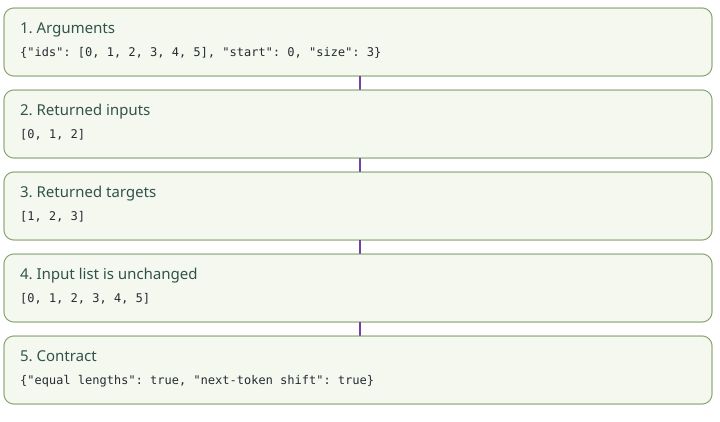

In [4]:
draw_trace()

### P0.6.3 · Read and run the code

Read the function signature as its input contract. The size argument has a default; the start argument is supplied by name in the call.

The conditional rejects negative starts, empty windows and a final input without a target. Raising ValueError explains the violated requirement.

Return creates the two slices. A caller that does not return a value explicitly instead hands back None.

Assign the returned inputs to x and the returned targets to y. Local variables inside the function do not automatically become names in the caller's scope.

Avoid mutable default containers for accumulated results. Use None as a sentinel and construct a new list within each call when independent state is intended.

### Change one thing

**Move start from 0 to 1**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
def window(ids: list[int], start: int, size: int = 3):
    if start < 0 or size < 1 or start + size >= len(ids):
        raise ValueError("Need a complete window plus its next target")
    return ids[start:start+size], ids[start+1:start+size+1]
ids = [0, 1, 2, 3, 4, 5]
show("Arguments", {"ids": ids, "start": change, "size": 3})
x, y = window(ids, start=change)
show("Returned inputs", x)
show("Returned targets", y)
show("Input list is unchanged", ids)
show("Contract", {"equal lengths": len(x) == len(y), "next-token shift": x[1:] == y[:-1]})

Arguments: {"ids": [0, 1, 2, 3, 4, 5], "start": 1, "size": 3}
Returned inputs: [1, 2, 3]
Returned targets: [2, 3, 4]
Input list is unchanged: [0, 1, 2, 3, 4, 5]
Contract: {"equal lengths": true, "next-token shift": true}


### A useful distinction

Type hints do not validate values at runtime, and a mutable default object is shared between calls.

In [6]:
for args in [([0,1],0,2), ([0,1,2],-1,1), ([0,1,2],0,0)]:
    try:
        window(*args)
    except ValueError as error:
        print(error)
    else:
        raise AssertionError("Invalid window was accepted")

Need a complete window plus its next target
Need a complete window plus its next target
Need a complete window plus its next target


### ✋ Your turn

Use window on IDs [0,1,2,3,4] with start=1 and size=2; put the returned tuple in answer.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2], [2, 3]), 'Type hints do not validate values at runtime, and a mutable default object is shared between calls.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
answer = window([0, 1, 2, 3, 4], start=1, size=2)

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ([1, 2], [2, 3]), 'Type hints do not validate values at runtime, and a mutable default object is shared between calls.'
    print("✓ right:", answer)

✓ right: ([1, 2], [2, 3])


### P0.6.4 · Find it in the model

The model's forward method accepts token IDs and optionally targets. Without targets it can return predictions and no loss.

Training passes both inputs and targets; generation passes only inputs. A clear return contract keeps both call sites readable.

Batch functions should make boundary behavior explicit. A silently shortened slice is legal Python but may violate the model's expected batch shape.

Assertions are useful during experiments; explicit exceptions provide input validation that remains active when Python assertions are disabled.

Next, apply the same contracts at the file and configuration boundaries of a program.

```python
def forward(self, idx, targets=None):
    ...
    return logits, loss
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Can three source positions supply three next-character targets?

<details><summary>Check your explanation</summary>

No; a fourth source position is needed. Type hints do not validate values at runtime, and a mutable default object is shared between calls.

</details>